# AI Gateway — End-to-End Tests via Docker

This notebook tests all three AI models exposed through the server's `/api/ai` gateway.  
Requests are sent to the **locally running Docker container** (`http://localhost:8000`).

## Prerequisites

Start the dev stack from the repo root:
```bash
docker compose -f Server/docker/docker-compose.dev.yml up --build
```

The server runs at **http://localhost:8000**.  
Models are lazy-loaded — the first call to each endpoint will download weights (multi-GB) if not already cached.

| Model | Task | HF ID | Typical size |
|---|---|---|---|
| Whisper Large V3 | Speech-to-Text | `openai/whisper-large-v3` | ~3 GB |
| Swin2SR | Image SR ×2 | `caidas/swin2SR-classical-sr-x2-64` | ~60 MB |
| SD-x4 Upscaler | Image SR ×4 (text-guided) | `stabilityai/stable-diffusion-x4-upscaler` | ~5 GB |

In [1]:
import requests
import base64
import io
import os
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

BASE_URL = "http://localhost:8000"
DATASET_DIR = Path("dataset/dataset_audio/audio_files")
WAV_DIR = DATASET_DIR / "wavs"
METADATA_CSV = DATASET_DIR / "metadata.csv"

def check_response(resp: requests.Response, label: str):
    if resp.status_code not in (200, 204):
        print(f"[FAIL] {label}: HTTP {resp.status_code}")
        print(resp.text[:500])
        return False
    print(f"[OK]   {label}: HTTP {resp.status_code}")
    return True

print("Setup complete. BASE_URL =", BASE_URL)

Setup complete. BASE_URL = http://localhost:8000


## 1. Server Health Check

In [2]:
resp = requests.get(f"{BASE_URL}/api/health", timeout=10)
if check_response(resp, "GET /api/health"):
    print(resp.json())
else:
    raise SystemExit("Server not reachable. Run: docker compose -f Server/docker/docker-compose.dev.yml up --build")

[OK]   GET /api/health: HTTP 200
{'status': 'ok', 'version': '1.0.0'}


## 2. AI Gateway Status

Lists all registered models and whether their weights are currently loaded in memory.

In [11]:
resp = requests.get(f"{BASE_URL}/api/ai/status", timeout=10)
check_response(resp, "GET /api/ai/status")
status_data = resp.json()
print(f"\nGateway status: {status_data['status']}")
print(f"{'Model':<25} {'Task':<35} {'Loaded':<10} {'Device'}")
print("-" * 85)
for m in status_data["models"]:
    print(f"{m['name']:<25} {m['task']:<35} {str(m['is_loaded']):<10} {m['device']}")

[OK]   GET /api/ai/status: HTTP 200

Gateway status: ok
Model                     Task                                Loaded     Device
-------------------------------------------------------------------------------------
Swin2SR                   image-super-resolution-x2           True       cpu
Whisper-Large-V3          automatic-speech-recognition        True       cpu


---
## 3. Whisper Large V3 — Automatic Speech Recognition

Dataset: LJSpeech — English audiobook recordings with ground-truth transcriptions.  
We post WAV files to `/api/ai/transcribe/whisper` and measure WER/CER.

In [14]:
# Wake Whisper (downloads ~3 GB on first run — takes a few minutes)
print("Waking Whisper Large V3 (may download weights on first run)...")
t0 = time.time()
resp = requests.post(f"{BASE_URL}/api/ai/models/whisper/wake", timeout=600)
elapsed = time.time() - t0
if check_response(resp, "POST /api/ai/models/whisper/wake"):
    info = resp.json()["model"]
    print(f"  Loaded: {info['is_loaded']}  Device: {info['device']}  (took {elapsed:.1f}s)")

Waking Whisper Large V3 (may download weights on first run)...
[OK]   POST /api/ai/models/whisper/wake: HTTP 200
  Loaded: True  Device: cpu  (took 204.1s)


In [15]:
# Load metadata for ground-truth transcriptions
metadata = {}
with open(METADATA_CSV, newline="", encoding="utf-8") as f:
    for row in csv.reader(f, delimiter="|"):
        if len(row) >= 2:
            metadata[row[0].strip()] = row[1].strip()   # file_id → normalized text

print(f"Loaded {len(metadata)} transcriptions from metadata.csv")
print("Sample entry:", list(metadata.items())[10])

Loaded 13100 transcriptions from metadata.csv
Sample entry: ('LJ001-0011', 'it is of the first importance that the letter used should be fine in form;')


In [16]:
# Single transcription — LJ001-0011
sample_id = "LJ001-0011"
wav_path = WAV_DIR / f"{sample_id}.wav"
ground_truth = metadata.get(sample_id, "")

print(f"File     : {wav_path}")
print(f"Reference: {ground_truth}\n")

with open(wav_path, "rb") as f:
    resp = requests.post(
        f"{BASE_URL}/api/ai/transcribe/whisper",
        files={"file": (f"{sample_id}.wav", f, "audio/wav")},
        data={"expected_text": ground_truth, "language": "en"},
        timeout=120,
    )

if check_response(resp, "POST /api/ai/transcribe/whisper"):
    result = resp.json()
    print(f"Transcription: {result['transcription']}")
    print("\nMetrics:")
    for k, v in result["metrics"].items():
        print(f"  {k:<25}: {v}")

File     : dataset\dataset_audio\audio_files\wavs\LJ001-0011.wav
Reference: it is of the first importance that the letter used should be fine in form;

[OK]   POST /api/ai/transcribe/whisper: HTTP 200
Transcription: It is of the first importance that the letter used should be fine in form,

Metrics:
  inference_time_s         : 15.2262
  audio_duration_s         : 4.51
  rtf                      : 3.3748
  num_tokens               : 15
  gpu_peak_mb              : 0
  device                   : cpu
  sample_rate              : 16000
  audio_rms                : 0.093931
  audio_peak               : 0.777272
  wer                      : 0.1333
  cer                      : 0.027


In [ ]:
# Batch evaluation on 5 samples — compare WER across files
SAMPLE_IDS = [f"LJ001-{i:04d}" for i in range(11, 16)]

results_whisper = []
for sid in SAMPLE_IDS:
    wav_path = WAV_DIR / f"{sid}.wav"
    if not wav_path.exists():
        print(f"  [SKIP] {sid}.wav not found")
        continue
    gt = metadata.get(sid, "")
    with open(wav_path, "rb") as f:
        resp = requests.post(
            f"{BASE_URL}/api/ai/transcribe/whisper",
            files={"file": (f"{sid}.wav", f, "audio/wav")},
            data={"expected_text": gt, "language": "en"},
            timeout=120,
        )
    if resp.status_code == 200:
        r = resp.json()
        results_whisper.append({
            "id": sid,
            "reference": gt,
            "hypothesis": r["transcription"],
            **r["metrics"],
        })
        print(f"{sid}  RTF={r['metrics']['rtf']:.3f}  WER={r['metrics'].get('wer', 'N/A')}")
    else:
        print(f"  [FAIL] {sid}: {resp.status_code}")

if results_whisper:
    avg_wer = np.mean([r["wer"] for r in results_whisper if "wer" in r])
    avg_rtf = np.mean([r["rtf"] for r in results_whisper])
    print(f"\nBatch average — WER: {avg_wer:.4f}  RTF: {avg_rtf:.4f}")

LJ001-0011  RTF=18.078  WER=0.1333
LJ001-0012  RTF=3.693  WER=0.1176
LJ001-0013  RTF=10.557  WER=0.0
LJ001-0014  RTF=3.407  WER=0.1613
LJ001-0015  RTF=3.829  WER=0.0

Batch average — WER: 0.0824  RTF: 7.9130


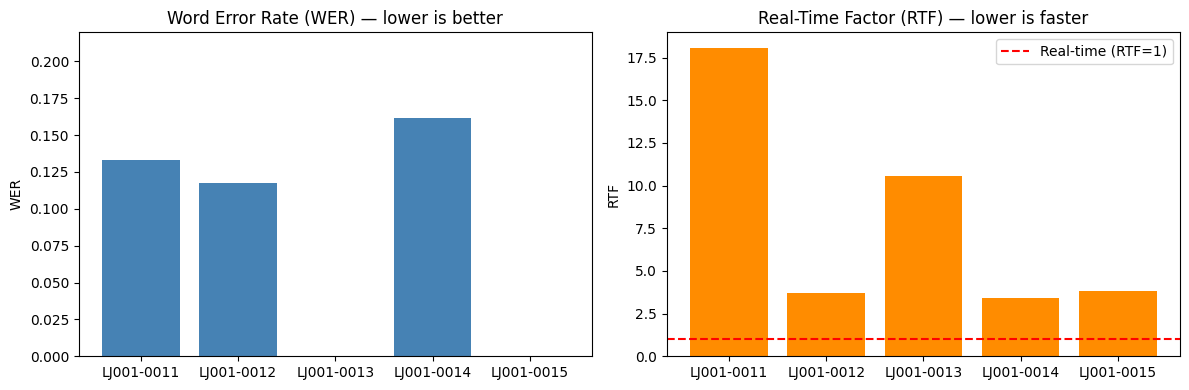

In [ ]:
# Visualise WER / RTF for each sample
if results_whisper:
    ids   = [r["id"] for r in results_whisper]
    wers  = [r.get("wer", 0) for r in results_whisper]
    rtfs  = [r["rtf"] for r in results_whisper]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(ids, wers, color="steelblue")
    axes[0].set_title("Word Error Rate (WER) — lower is better")
    axes[0].set_ylabel("WER")
    axes[0].set_ylim(0, max(wers) * 1.3 + 0.01)

    axes[1].bar(ids, rtfs, color="darkorange")
    axes[1].axhline(1.0, color="red", linestyle="--", label="Real-time (RTF=1)")
    axes[1].set_title("Real-Time Factor (RTF) — lower is faster")
    axes[1].set_ylabel("RTF")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

---
## 4. Swin2SR — Image Super-Resolution ×2

Posts a low-resolution image to `/api/ai/upscale/swin2sr` and displays the upscaled result.  
We generate a synthetic test image (gradient + text) so no external image files are needed.

In [7]:
# Wake Swin2SR (~60 MB — fast)
print("Waking Swin2SR...")
t0 = time.time()
resp = requests.post(f"{BASE_URL}/api/ai/models/swin2sr/wake", timeout=300)
elapsed = time.time() - t0
if check_response(resp, "POST /api/ai/models/swin2sr/wake"):
    info = resp.json()["model"]
    print(f"  Loaded: {info['is_loaded']}  Device: {info['device']}  (took {elapsed:.1f}s)")

Waking Swin2SR...
[OK]   POST /api/ai/models/swin2sr/wake: HTTP 200
  Loaded: True  Device: cpu  (took 37.5s)


Test image size: (128, 128)


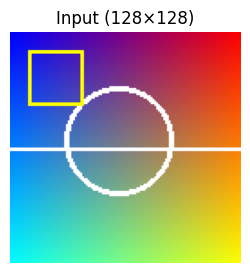

In [8]:
def make_test_image(width=128, height=128) -> Image.Image:
    """Generate a synthetic low-res image with gradient + geometric shapes."""
    img = Image.new("RGB", (width, height))
    pixels = img.load()
    for y in range(height):
        for x in range(width):
            r = int(255 * x / width)
            g = int(255 * y / height)
            b = int(255 * (1 - x / width))
            pixels[x, y] = (r, g, b)
    draw = ImageDraw.Draw(img)
    draw.ellipse([30, 30, 90, 90], outline="white", width=3)
    draw.rectangle([10, 10, 40, 40], outline="yellow", width=2)
    draw.line([0, height // 2, width, height // 2], fill="white", width=2)
    return img

lr_image = make_test_image(128, 128)
print(f"Test image size: {lr_image.size}")
plt.figure(figsize=(3, 3))
plt.imshow(lr_image)
plt.title("Input (128×128)")
plt.axis("off")
plt.show()

Calling /api/ai/upscale/swin2sr ...
[OK]   POST /api/ai/upscale/swin2sr: HTTP 200
  Output size : (272, 272)
  Wall time   : 27.55s
  Metrics:
    inference_time_s         : 6.3647
    input_size               : 128x128
    output_size              : 272x272
    scale_factor             : 2
    device                   : cpu
    sharpness                : 907.0257
    entropy                  : 7.5758
    contrast                 : 54.3282


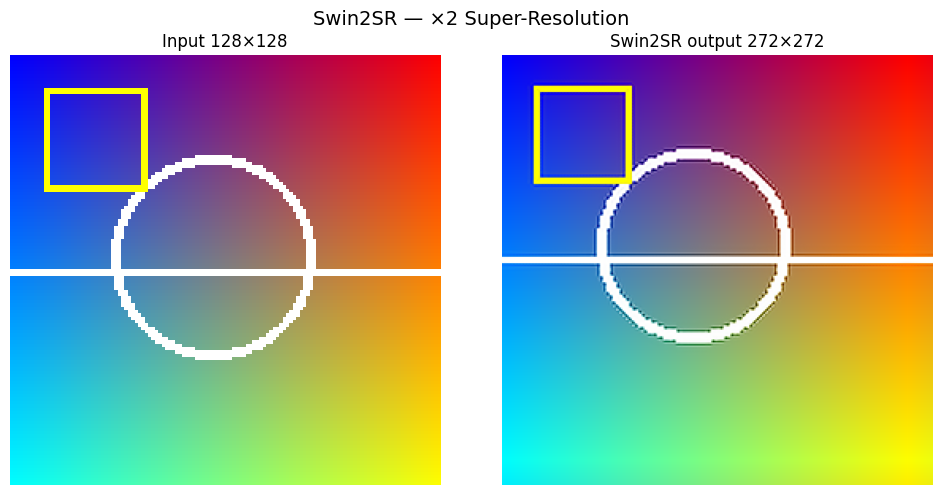

In [9]:
# Upload to Swin2SR endpoint
buf = io.BytesIO()
lr_image.save(buf, format="PNG")
buf.seek(0)

print("Calling /api/ai/upscale/swin2sr ...")
t0 = time.time()
resp = requests.post(
    f"{BASE_URL}/api/ai/upscale/swin2sr",
    files={"file": ("test.png", buf, "image/png")},
    timeout=120,
)
elapsed = time.time() - t0

if check_response(resp, "POST /api/ai/upscale/swin2sr"):
    data = resp.json()
    sr_bytes = base64.b64decode(data["image_base64"])
    sr_image = Image.open(io.BytesIO(sr_bytes))
    print(f"  Output size : {sr_image.size}")
    print(f"  Wall time   : {elapsed:.2f}s")
    print("  Metrics:")
    for k, v in data["metrics"].items():
        print(f"    {k:<25}: {v}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(lr_image)
    axes[0].set_title(f"Input {lr_image.size[0]}×{lr_image.size[1]}")
    axes[0].axis("off")
    axes[1].imshow(sr_image)
    axes[1].set_title(f"Swin2SR output {sr_image.size[0]}×{sr_image.size[1]}")
    axes[1].axis("off")
    plt.suptitle("Swin2SR — ×2 Super-Resolution", fontsize=14)
    plt.tight_layout()
    plt.show()

### Swin2SR — quality metrics at different resolutions

Upscale three different input sizes to see how sharpness and inference time scale.

In [ ]:
swin_results = []
for sz in [64, 128, 256]:
    img = make_test_image(sz, sz)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    t0 = time.time()
    resp = requests.post(
        f"{BASE_URL}/api/ai/upscale/swin2sr",
        files={"file": ("test.png", buf, "image/png")},
        timeout=180,
    )
    wall = time.time() - t0
    if resp.status_code == 200:
        m = resp.json()["metrics"]
        swin_results.append({"input_size": m["input_size"], "output_size": m["output_size"],
                              "inference_s": m["inference_time_s"], "sharpness": m["sharpness"],
                              "wall_s": round(wall, 2)})
        print(f"{sz:>3}px → {m['output_size']}  inference={m['inference_time_s']:.3f}s  sharpness={m['sharpness']}")
    else:
        print(f"{sz}px → FAIL {resp.status_code}")

---
## 5. Stable Diffusion ×4 Upscaler — Text-Guided Super-Resolution

Posts an image **and** a text prompt to `/api/ai/upscale/sd-x4`.  
The model adds generated details guided by the prompt — output is 4× the input resolution.

> **Note:** On CPU this takes **5–20 minutes** per image (25 denoising steps).  
> Use fewer `num_inference_steps` (e.g. 5–10) for quick smoke tests.

In [ ]:
# Wake SD-x4 (~5 GB on first run — may take several minutes to download)
print("Waking SD-x4 Upscaler (may download ~5 GB on first run)...")
t0 = time.time()
resp = requests.post(f"{BASE_URL}/api/ai/models/sd-x4/wake", timeout=1200)
elapsed = time.time() - t0
if check_response(resp, "POST /api/ai/models/sd-x4/wake"):
    info = resp.json()["model"]
    print(f"  Loaded: {info['is_loaded']}  Device: {info['device']}  (took {elapsed:.1f}s)")

In [ ]:
# Run SD-x4 upscale — use 5 steps for a fast smoke test
sd_input = make_test_image(64, 64)     # 64×64 → 256×256
buf = io.BytesIO()
sd_input.save(buf, format="PNG")
buf.seek(0)

PROMPT = "vibrant abstract geometric shapes, high quality, 4K"
STEPS  = 5    # increase to 25 for better quality (much slower on CPU)

print(f"Calling /api/ai/upscale/sd-x4  (steps={STEPS}, prompt='{PROMPT}')...")
t0 = time.time()
resp = requests.post(
    f"{BASE_URL}/api/ai/upscale/sd-x4",
    files={"file": ("test.png", buf, "image/png")},
    data={
        "prompt": PROMPT,
        "num_inference_steps": str(STEPS),
        "guidance_scale": "7.5",
        "seed": "42",
    },
    timeout=1800,   # generous timeout for CPU inference
)
elapsed = time.time() - t0

if check_response(resp, "POST /api/ai/upscale/sd-x4"):
    data = resp.json()
    sr_bytes = base64.b64decode(data["image_base64"])
    sd_output = Image.open(io.BytesIO(sr_bytes))
    print(f"  Output size : {sd_output.size}")
    print(f"  Wall time   : {elapsed:.2f}s")
    print("  Metrics:")
    for k, v in data["metrics"].items():
        print(f"    {k:<25}: {v}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(sd_input)
    axes[0].set_title(f"Input {sd_input.size[0]}×{sd_input.size[1]}")
    axes[0].axis("off")
    axes[1].imshow(sd_output)
    axes[1].set_title(f"SD-x4 output {sd_output.size[0]}×{sd_output.size[1]}")
    axes[1].axis("off")
    plt.suptitle(f"SD ×4 Upscaler — '{PROMPT}'", fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 6. Summary

Check all models are still loaded and print final gateway status.

In [10]:
resp = requests.get(f"{BASE_URL}/api/ai/status", timeout=10)
status_data = resp.json()
print(f"\nFinal gateway status: {status_data['status']}")
print(f"{'Model':<25} {'Task':<35} {'Loaded':<10} {'Device'}")
print("-" * 85)
for m in status_data["models"]:
    loaded_str = "✓ yes" if m["is_loaded"] else "✗ no"
    print(f"{m['name']:<25} {m['task']:<35} {loaded_str:<10} {m['device']}")

print("\n" + "=" * 60)
print("Whisper batch results:")
if results_whisper:
    for r in results_whisper:
        print(f"  {r['id']}  WER={r.get('wer','N/A')}  CER={r.get('cer','N/A')}  RTF={r['rtf']:.3f}")

print("\nSwin2SR scaling results:")
for r in swin_results:
    print(f"  {r['input_size']} → {r['output_size']}  inference={r['inference_s']}s  sharpness={r['sharpness']}")


Final gateway status: ok
Model                     Task                                Loaded     Device
-------------------------------------------------------------------------------------
Swin2SR                   image-super-resolution-x2           ✓ yes      cpu
Whisper-Large-V3          automatic-speech-recognition        ✓ yes      cpu

Whisper batch results:


NameError: name 'results_whisper' is not defined

---
## 7. LLM Gateway — Groq (same model as the planning agent)

The server exposes the Groq LLM used by the planning agent as a standalone gateway
under `/api/ai/llm/`.  Tools can call this directly to get text completions without
going through the full agent loop.

| Endpoint | Method | Description |
|---|---|---|
| `/api/ai/llm/status` | GET | Check API key is configured |
| `/api/ai/llm/generate` | POST | Blocking — returns full response |
| `/api/ai/llm/stream` | POST | Streaming SSE — token by token |

Body fields: `prompt` (required), `system` (optional), `temperature` (0–1), `max_output_tokens`.

In [ ]:
# ── 7.1  Status check ────────────────────────────────────────────────────────
resp = requests.get(f"{BASE_URL}/api/ai/llm/status", timeout=10)
if check_response(resp, "GET /api/ai/llm/status"):
    data = resp.json()
    icon = "✓" if data["configured"] else "✗"
    print(f"  {icon} configured : {data['configured']}")
    print(f"    model       : {data['model']}")
    print(f"    detail      : {data['detail']}")
    if not data["configured"]:
        raise SystemExit("GROQ_API_KEY not set on the server — set it in Server/src/.env")

In [ ]:
# ── 7.2  Simple generate — blocking ──────────────────────────────────────────
payload = {
    "prompt": "Explain what a ReAct agent is in 2 sentences.",
    "temperature": 0.3,
    "max_output_tokens": 256,
}

print(f"Prompt : {payload['prompt']}\n")
t0 = time.time()
resp = requests.post(f"{BASE_URL}/api/ai/llm/generate", json=payload, timeout=60)
wall = time.time() - t0

if check_response(resp, "POST /api/ai/llm/generate"):
    result = resp.json()
    print(f"Model   : {result['model']}")
    print(f"Latency : {result['latency_s']} s  (wall: {wall:.2f} s)")
    print(f"\nResponse:\n{result['text']}")

In [ ]:
# ── 7.3  System prompt — custom persona ──────────────────────────────────────
payload_sys = {
    "prompt": "What tools do you have available and what can you do?",
    "system": (
        "You are a helpful file-management assistant built into the Licenta desktop app. "
        "You can convert images, compress videos, generate subtitles, and analyze disk space. "
        "Answer concisely in 3 bullet points."
    ),
    "temperature": 0.5,
    "max_output_tokens": 512,
}

print(f"System : {payload_sys['system'][:80]}...")
print(f"Prompt : {payload_sys['prompt']}\n")

resp = requests.post(f"{BASE_URL}/api/ai/llm/generate", json=payload_sys, timeout=60)
if check_response(resp, "POST /api/ai/llm/generate (system prompt)"):
    r = resp.json()
    print(f"Latency: {r['latency_s']} s\n")
    print(r["text"])

In [ ]:
# ── 7.4  Streaming SSE — token-by-token ──────────────────────────────────────
import sseclient  # pip install sseclient-py  (or use manual parsing below)

payload_stream = {
    "prompt": "List 5 interesting facts about video codecs, one per line.",
    "temperature": 0.7,
    "max_output_tokens": 512,
}

print(f"Prompt: {payload_stream['prompt']}\n")
print("─" * 60)

token_count = 0
full_text   = ""
latency_s   = None

try:
    with requests.post(
        f"{BASE_URL}/api/ai/llm/stream",
        json=payload_stream,
        stream=True,
        timeout=120,
    ) as resp:
        resp.raise_for_status()
        buf = ""
        for raw in resp.iter_content(chunk_size=None):
            buf += raw.decode("utf-8", errors="replace")
            while "\n\n" in buf:
                part, buf = buf.split("\n\n", 1)
                for line in part.split("\n"):
                    if not line.startswith("data: "):
                        continue
                    import json as _json
                    evt = _json.loads(line[6:])
                    if evt["stage"] == "token":
                        print(evt["text"], end="", flush=True)
                        token_count += 1
                    elif evt["stage"] == "done":
                        full_text = evt["text"]
                        latency_s = evt["latency_s"]
                    elif evt["stage"] == "error":
                        print(f"\n[ERROR] {evt['message']}")
except Exception as exc:
    print(f"\n[STREAM ERROR] {exc}")

print(f"\n{'─'*60}")
print(f"Tokens streamed : {token_count}")
print(f"Server latency  : {latency_s} s")
print(f"Total chars     : {len(full_text)}")

In [ ]:
# ── 7.5  Batch: latency across temperatures ──────────────────────────────────
PROMPT_BATCH = "In one sentence, describe what machine learning is."
TEMPERATURES = [0.0, 0.3, 0.7, 1.0]

llm_results = []
for temp in TEMPERATURES:
    t0 = time.time()
    resp = requests.post(
        f"{BASE_URL}/api/ai/llm/generate",
        json={"prompt": PROMPT_BATCH, "temperature": temp, "max_output_tokens": 128},
        timeout=60,
    )
    wall = round(time.time() - t0, 3)
    if resp.status_code == 200:
        r = resp.json()
        llm_results.append({"temperature": temp, "latency_s": r["latency_s"],
                             "wall_s": wall, "chars": len(r["text"]), "text": r["text"]})
        print(f"  temp={temp:.1f}  latency={r['latency_s']}s  chars={len(r['text'])}")
        print(f"    → {r['text'][:100]}")
    else:
        print(f"  temp={temp:.1f}  FAIL {resp.status_code}: {resp.text[:100]}")

# Plot latency vs temperature
if llm_results:
    temps    = [r["temperature"] for r in llm_results]
    latencies = [r["latency_s"] for r in llm_results]

    plt.figure(figsize=(7, 3))
    plt.plot(temps, latencies, "o-", color="mediumpurple", linewidth=2, markersize=8)
    plt.xlabel("Temperature")
    plt.ylabel("Server latency (s)")
    plt.title("LLM Gateway — latency vs temperature")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
#Optional: unload all models to free memory
# Uncomment to release GPU/RAM after testing

for name in ["whisper", "swin2sr", "sd-x4"]:
     r = requests.post(f"{BASE_URL}/api/ai/models/{name}/unload", timeout=30)
     print(f"Unload {name}: HTTP {r.status_code}")